In [1]:
import pandas as pd
import requests
from io import StringIO

In [2]:
res = requests.get('https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day37-handling-missing-categorical-data/train.csv').text
df = pd.read_csv(StringIO(res), usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])
libDf = df
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [3]:
df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

<Axes: xlabel='GarageQual'>

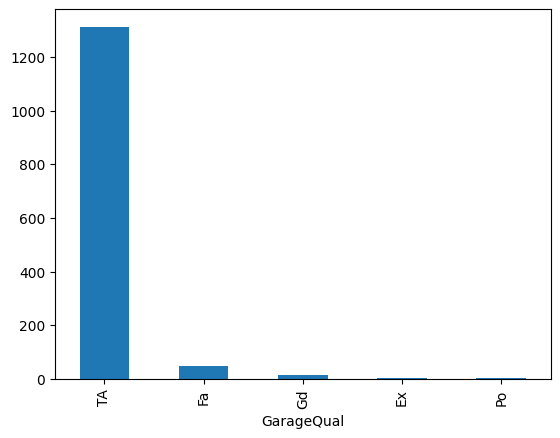

In [4]:
df['GarageQual'].value_counts().plot(kind='bar')

In [5]:
df['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: object

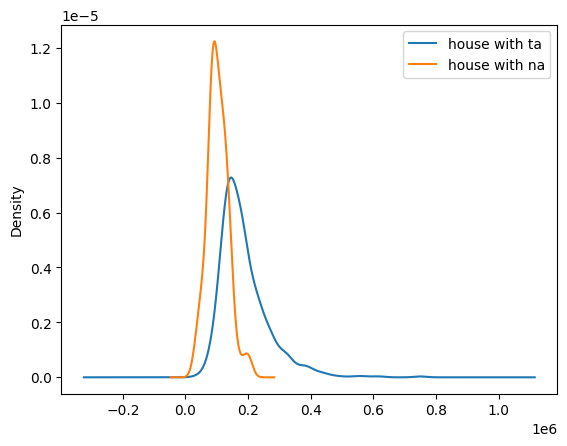

In [6]:
import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde', ax=ax, label = 'house with ta')
df[df['GarageQual'].isnull()]['SalePrice'].plot(kind = 'kde', ax = ax, label = 'house with na')
ax.legend()


In [7]:
temp = df[df['GarageQual']=='TA']['SalePrice']
df.fillna({'GarageQual': 'TA'}, inplace=True)

<Axes: xlabel='GarageQual'>

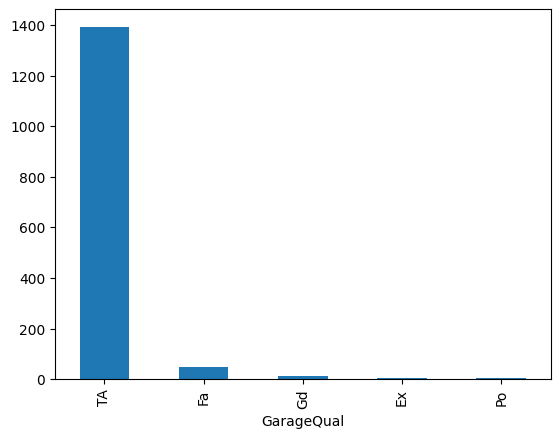

In [8]:
df['GarageQual'].value_counts().plot(kind='bar')

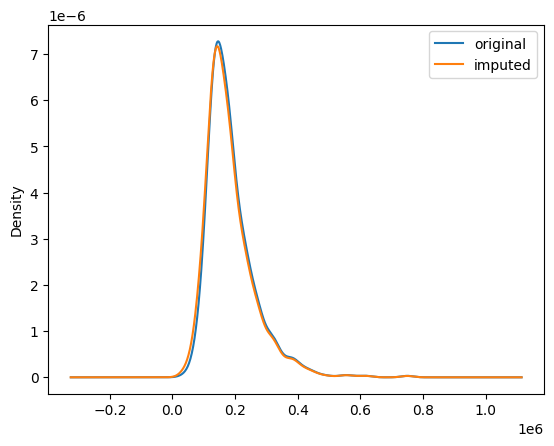

In [9]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind='kde', ax=ax, label = 'original')
df[df['GarageQual']=='TA']['SalePrice'].plot(kind = 'kde', ax = ax, label = 'imputed')
ax.legend()


<Axes: xlabel='FireplaceQu'>

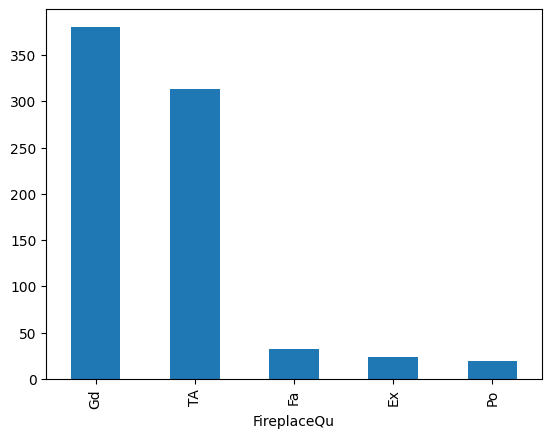

In [10]:
df['FireplaceQu'].value_counts().plot(kind='bar')

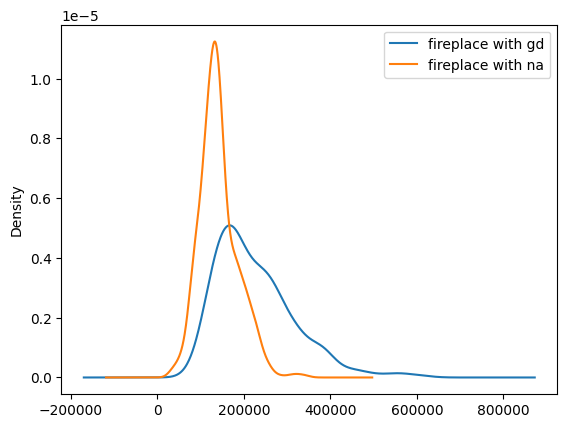

In [11]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind = 'kde', ax = ax, label = 'fireplace with gd')
df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind = 'kde', ax = ax, label = 'fireplace with na')
ax.legend()

In [12]:
temp = df[df['FireplaceQu']=='Gd']['SalePrice']
df.fillna({'FireplaceQu': 'Gd'}, inplace=True)

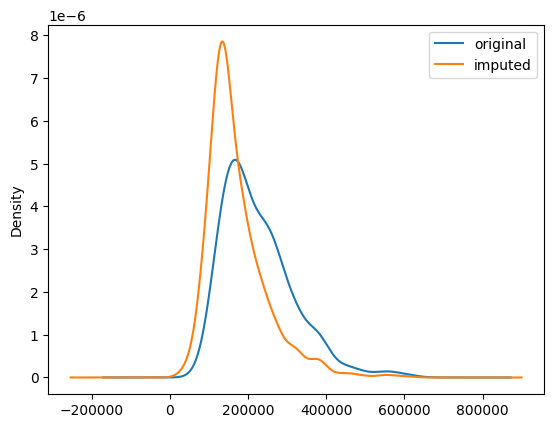

In [13]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind='kde', ax=ax, label = 'original')
df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind = 'kde', ax = ax, label = 'imputed')
ax.legend()


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
x_train, x_test, y_train, y_test = train_test_split(libDf.iloc[:,:2], libDf.iloc[:, [-1]], test_size=0.2, random_state=42)
imp = SimpleImputer(strategy='most_frequent')
x_train = imp.fit_transform(x_train)
x_test = imp.fit_transform(x_test)

In [18]:
imp.statistics_

array(['Gd', 'TA'], dtype=object)